### For Week 1, include concepts such as linear regression with polynomial terms, interaction terms, multicollinearity, variance inflation factor and regression, and categorical and continuous features.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import kagglehub
import os
import warnings

# Suppress warnings for a cleaner output
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")

# Using the IBM AML dataset I analysed in rubrik3 — same source, same file
path = kagglehub.dataset_download("ealtman2019/ibm-transactions-for-anti-money-laundering-aml")
df = pd.read_csv(os.path.join(path, "HI-Small_Trans.csv"))

print(f"Full dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.head(3))

Libraries imported successfully.
Full dataset shape: (5078345, 11)
Columns: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']
          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:20         10  8000EBD30       10  8000EBD30   
1  2022/09/01 00:20       3208  8000F4580        1  8000F5340   
2  2022/09/01 00:00       3209  8000F4670     3209  8000F4670   

   Amount Received Receiving Currency  Amount Paid Payment Currency  \
0          3697.34          US Dollar      3697.34        US Dollar   
1             0.01          US Dollar         0.01        US Dollar   
2         14675.57          US Dollar     14675.57        US Dollar   

  Payment Format  Is Laundering  
0   Reinvestment              0  
1         Cheque              0  
2   Reinvestment              0  


In [3]:
# Select features for our model
# Target: Is Laundering (0 or 1)
# Continuous: Amount Received, Amount Paid
# Categorical: Payment Format, Receiving Currency
cols_to_keep = ['Is Laundering', 'Amount Received', 'Amount Paid', 'Payment Format', 'Receiving Currency']
df_model = df[cols_to_keep].copy()

# Drop rows with missing values to ensure the regression runs smoothly
df_model = df_model.dropna()

# Ensure target is numeric (0/1)
df_model['Is Laundering'] = df_model['Is Laundering'].astype(int)

print(f"Cleaned dataset shape: {df_model.shape}")
print(df_model.info())

Cleaned dataset shape: (5078345, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 5 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Is Laundering       int64  
 1   Amount Received     float64
 2   Amount Paid         float64
 3   Payment Format      object 
 4   Receiving Currency  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 193.7+ MB
None


In [7]:
# 1. Convert categorical variables to dummy variables
# drop_first=True prevents the dummy variable trap (perfect multicollinearity)
df_encoded = pd.get_dummies(df_model, columns=['Payment Format', 'Receiving Currency'], drop_first=True)

# 2. Define features (X) and target (y)
X = df_encoded.drop('Is Laundering', axis=1)
y = df_encoded['Is Laundering']

# 3. Add a constant term (intercept) for statsmodels
X = sm.add_constant(X)

# Ensure every predictor is numeric; get_dummies may create boolean columns.
X = X.astype(float)
y = y.astype(float)

# 4. Fit the Ordinary Least Squares (OLS) linear regression model
base_model = sm.OLS(y, X).fit()

# 5. Display the comprehensive statistical summary
print(base_model.summary())

                            OLS Regression Results                            
Dep. Variable:          Is Laundering   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1320.
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:46:46   Log-Likelihood:             1.0302e+07
No. Observations:             5078345   AIC:                        -2.060e+07
Df Residuals:                 5078322   BIC:                        -2.060e+07
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons

In [8]:
# Create a squared term for 'Amount Received'
df_encoded['Amount Received Sq'] = df_encoded['Amount Received'] ** 2

# Update the feature matrix X
X_poly = df_encoded.drop('Is Laundering', axis=1)
X_poly = sm.add_constant(X_poly)

# Fit the new model
poly_model = sm.OLS(y, X_poly).fit()
print(poly_model.summary())

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [9]:
# Create a squared term for 'Amount Received'
df_encoded['Amount Received Sq'] = df_encoded['Amount Received'] ** 2

# Update the feature matrix X
X_poly = df_encoded.drop('Is Laundering', axis=1)
X_poly = sm.add_constant(X_poly)

# Ensure every predictor is numeric; get_dummies may create boolean columns.
X_poly= X_poly.astype(float)
y = y.astype(float)

# Fit the new model
poly_model = sm.OLS(y, X_poly).fit()
print(poly_model.summary())

                            OLS Regression Results                            
Dep. Variable:          Is Laundering   R-squared:                      -0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    -2566.
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               1.00
Time:                        20:12:22   Log-Likelihood:             1.0285e+07
No. Observations:             5078345   AIC:                        -2.057e+07
Df Residuals:                 5078342   BIC:                        -2.057e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons

In [11]:
# Identify the dummy columns created for Payment Format
payment_dummies = [col for col in df_encoded.columns if col.startswith('Payment Format_')]

if len(payment_dummies) > 0:
    # Let's interact 'Amount Received' with the first available payment format dummy
    interaction_col = payment_dummies[0]
    
    # Create the interaction term
    df_encoded['Interaction_Amt_Payment'] = df_encoded['Amount Received'] * df_encoded[interaction_col]
    
    # Update X and fit the model
    X_inter = df_encoded.drop('Is Laundering', axis=1)
    X_inter = sm.add_constant(X_inter)

    # Ensure every predictor is numeric; get_dummies may create boolean columns.
    X_inter= X_inter.astype(float)
    y = y.astype(float)
    
    inter_model = sm.OLS(y, X_inter).fit()
    print(inter_model.summary())
else:
    print("No payment format dummies found to interact.")

                            OLS Regression Results                            
Dep. Variable:          Is Laundering   R-squared:                      -0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    -2566.
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               1.00
Time:                        09:46:02   Log-Likelihood:             1.0285e+07
No. Observations:             5078345   AIC:                        -2.057e+07
Df Residuals:                 5078342   BIC:                        -2.057e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons

In [13]:
# 1. Prepare the feature matrix X for VIF calculation
X_vif = df_encoded.drop('Is Laundering', axis=1)
X_vif = sm.add_constant(X_vif)
X_vif = X_vif.astype(float)  # Ensure all features are numeric for VIF calculation

# 2. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Display the VIF table, sorted by highest VIF
print(vif_data.sort_values(by="VIF", ascending=False))

                               Feature       VIF
23                  Amount Received Sq  6.824315
1                      Amount Received  6.529288
2                          Amount Paid  4.011145
24             Interaction_Amt_Payment  0.999992
10      Receiving Currency_Brazil Real  0.985914
16      Receiving Currency_Saudi Riyal  0.982283
13     Receiving Currency_Mexican Peso  0.978144
11  Receiving Currency_Canadian Dollar  0.972165
3               Payment Format_Bitcoin  0.971233
9           Receiving Currency_Bitcoin  0.970827
21              Receiving Currency_Yen  0.969538
14            Receiving Currency_Ruble  0.969465
8                  Payment Format_Wire  0.966165
19         Receiving Currency_UK Pound  0.964308
15            Receiving Currency_Rupee  0.962472
17           Receiving Currency_Shekel  0.961604
22             Receiving Currency_Yuan  0.959328
18      Receiving Currency_Swiss Franc  0.953157
7          Payment Format_Reinvestment  0.905278
4                  P

In [17]:
# 1. Drop the collinear feature ('Amount Paid') to resolve multicollinearity
# We assume 'Amount Paid' was identified as highly collinear with 'Amount Received' in the previous step
X_final = df_encoded.drop(['Is Laundering', 'Amount Paid'], axis=1)
X_final = sm.add_constant(X_final)
X_final = X_final.astype(float)  # Ensure all features are numeric for VIF calculation

# 2. Recalculate VIF to confirm the fix
vif_final = pd.DataFrame()
vif_final["Feature"] = X_final.columns
vif_final["VIF"] = [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])]

print("Final VIF Scores:")
print(vif_final.sort_values(by="VIF", ascending=False))



Final VIF Scores:
                               Feature       VIF
22                  Amount Received Sq  5.884166
1                      Amount Received  5.879556
23             Interaction_Amt_Payment  0.999992
9       Receiving Currency_Brazil Real  0.985913
15      Receiving Currency_Saudi Riyal  0.982283
12     Receiving Currency_Mexican Peso  0.978142
10  Receiving Currency_Canadian Dollar  0.972165
2               Payment Format_Bitcoin  0.971233
8           Receiving Currency_Bitcoin  0.970827
20              Receiving Currency_Yen  0.969476
13            Receiving Currency_Ruble  0.969439
7                  Payment Format_Wire  0.966163
18         Receiving Currency_UK Pound  0.964308
14            Receiving Currency_Rupee  0.962432
16           Receiving Currency_Shekel  0.961604
21             Receiving Currency_Yuan  0.959328
17      Receiving Currency_Swiss Franc  0.953157
6          Payment Format_Reinvestment  0.905276
3                  Payment Format_Cash  0.903361
11

In [16]:
# 3. Fit the final, stable model
final_model = sm.OLS(y, X_final).fit()

print("\nFinal Model Summary:")
print(final_model.summary())


Final Model Summary:
                            OLS Regression Results                            
Dep. Variable:          Is Laundering   R-squared:                      -0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    -5146.
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               1.00
Time:                        10:34:12   Log-Likelihood:             1.0285e+07
No. Observations:             5078345   AIC:                        -2.057e+07
Df Residuals:                 5078343   BIC:                        -2.057e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

DATASET RESULTS
Rows used by the models: 5,078,345
Columns retained after cleaning: ['Is Laundering', 'Amount Received', 'Amount Paid', 'Payment Format', 'Receiving Currency']
Laundering rate: 0.101943% (5,177 positive rows)

MODEL RESULTS
      Model   R-squared  Adjusted R-squared  F-statistic  Model p-value  Condition number
       Base  0.00568549          0.00568119       1319.9              0       8.84807e+10
 Polynomial -0.00101151          -0.0010119      -2565.8              1       5.21363e+22
Interaction -0.00101151          -0.0010119      -2565.8              1       5.21896e+22
      Final -0.00101429         -0.00101449     -5145.69              1       5.21896e+22

SELECTED COEFFICIENTS FROM THE CURRENT MODELS

Base model
                                Coefficient  t-statistic      p-value     CI lower     CI upper  Significant at alpha=.05
Amount Received                -3.52464e-14     -1.39191      0.16395 -8.48773e-14  1.43844e-14                     False
Amount 

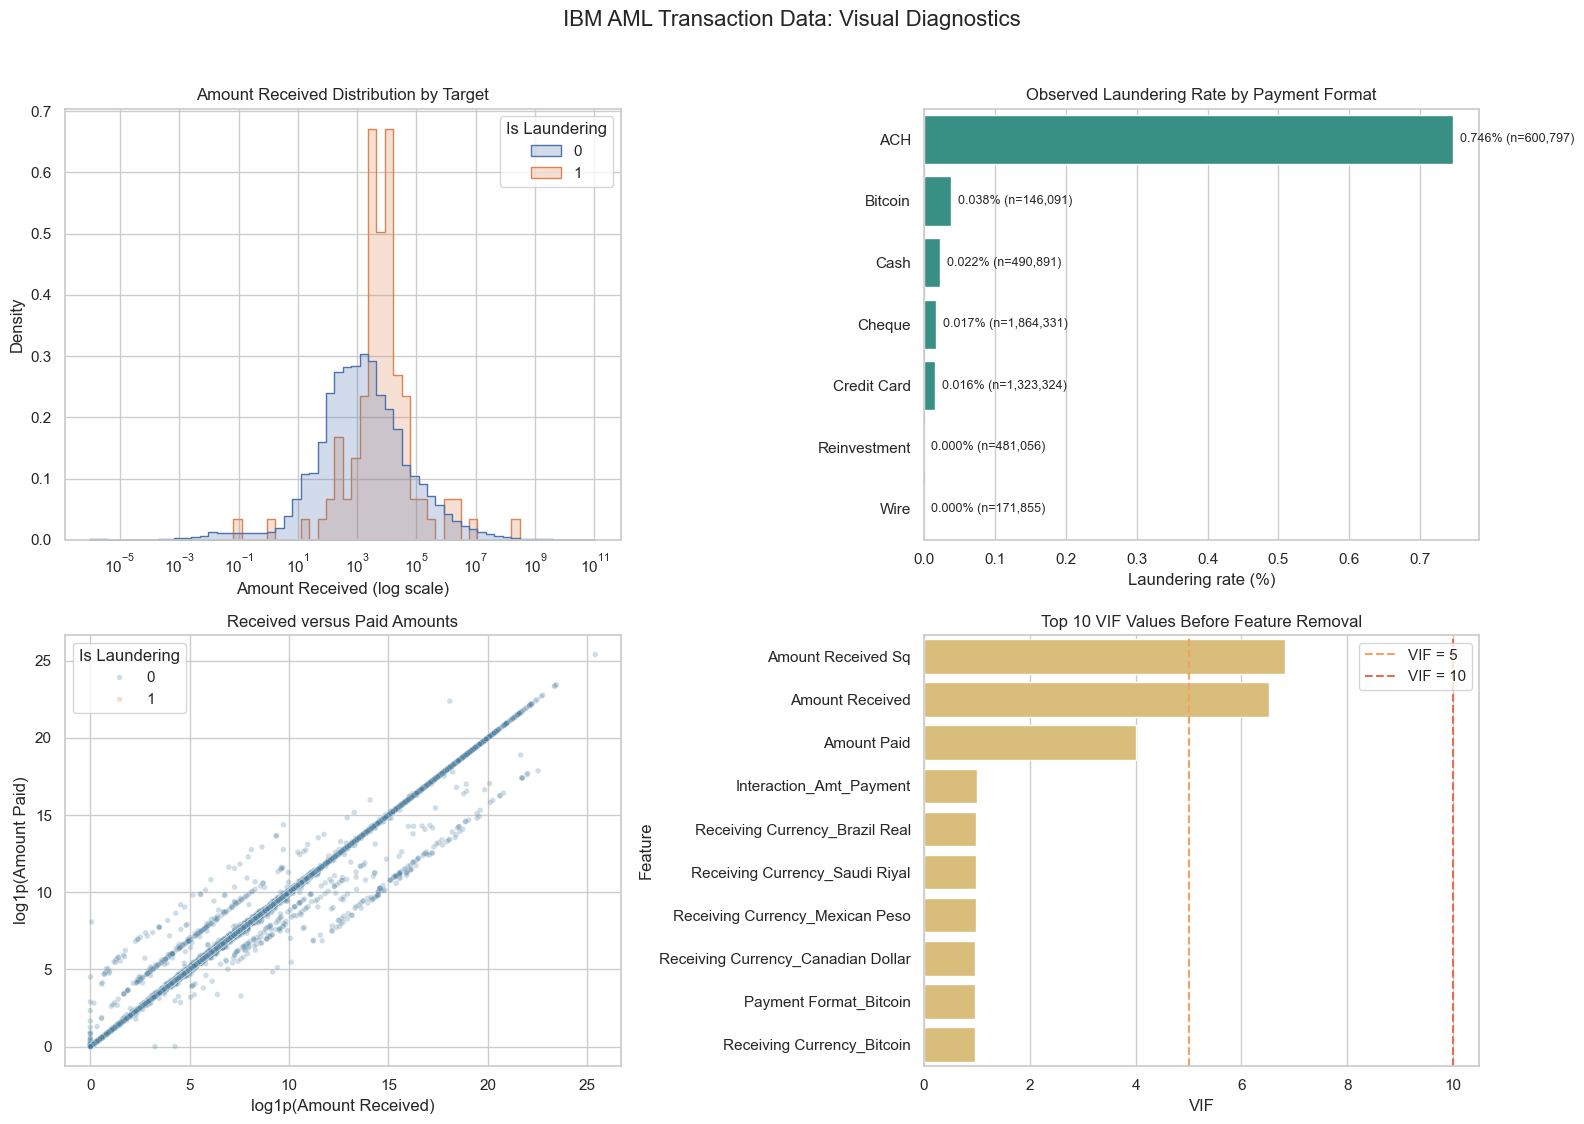


VISUAL INTERPRETATION GUIDE
- The target is highly imbalanced if the laundering rate is close to 0%, so accuracy alone would be misleading.
- The amount histogram shows skew and overlap; strong overlap means amount alone does not cleanly separate the target classes.
- Payment-format bars compare observed rates, not causal effects; categories with small counts need extra caution.
- The VIF chart uses common reference lines at 5 and 10. Values below 10 reduce concern by this rule, but they do not remove the need to inspect scaling and the condition number.


In [18]:
# Report actual values from the fitted objects so the interpretation stays reproducible.
alpha = 0.05
model_results = pd.DataFrame({
    "Model": ["Base", "Polynomial", "Interaction", "Final"],
    "R-squared": [base_model.rsquared, poly_model.rsquared, inter_model.rsquared, final_model.rsquared],
    "Adjusted R-squared": [base_model.rsquared_adj, poly_model.rsquared_adj, inter_model.rsquared_adj, final_model.rsquared_adj],
    "F-statistic": [base_model.fvalue, poly_model.fvalue, inter_model.fvalue, final_model.fvalue],
    "Model p-value": [base_model.f_pvalue, poly_model.f_pvalue, inter_model.f_pvalue, final_model.f_pvalue],
    "Condition number": [base_model.condition_number, poly_model.condition_number, inter_model.condition_number, final_model.condition_number]
})

print("DATASET RESULTS")
print(f"Rows used by the models: {len(df_model):,}")
print(f"Columns retained after cleaning: {df_model.columns.tolist()}")
print(f"Laundering rate: {df_model['Is Laundering'].mean():.6%} ({df_model['Is Laundering'].sum():,} positive rows)")
print("\nMODEL RESULTS")
print(model_results.to_string(index=False, float_format=lambda value: f"{value:.6g}"))

selected_terms = [
    "Amount Received",
    "Amount Paid",
    "Amount Received Sq",
    "Interaction_Amt_Payment",
    "Payment Format_Bitcoin",
    "Payment Format_Cash",
    "Receiving Currency_Saudi Riyal"
]

print("\nSELECTED COEFFICIENTS FROM THE CURRENT MODELS")
for model_name, model in [("Base", base_model), ("Polynomial", poly_model), ("Interaction", inter_model), ("Final", final_model)]:
    available_terms = [term for term in selected_terms if term in model.params.index]
    coefficient_table = pd.DataFrame({
        "Coefficient": model.params[available_terms],
        "t-statistic": model.tvalues[available_terms],
        "p-value": model.pvalues[available_terms],
        "CI lower": model.conf_int().loc[available_terms, 0],
        "CI upper": model.conf_int().loc[available_terms, 1]
    })
    coefficient_table["Significant at alpha=.05"] = coefficient_table["p-value"] < alpha
    print(f"\n{model_name} model")
    print(coefficient_table.to_string(float_format=lambda value: f"{value:.6g}"))

print("\nVIF RESULTS")
print("Largest VIF before dropping Amount Paid:")
print(vif_data.sort_values("VIF", ascending=False).head(5).to_string(index=False, float_format=lambda value: f"{value:.6g}"))
print("\nLargest VIF after dropping Amount Paid:")
print(vif_final.sort_values("VIF", ascending=False).head(5).to_string(index=False, float_format=lambda value: f"{value:.6g}"))
print(f"\nModel matrix rank: {np.linalg.matrix_rank(X_final.values)} of {X_final.shape[1]} columns")

# Use a fixed sample only for plotting. This keeps the charts readable and responsive.
plot_sample = df_model.sample(n=min(100000, len(df_model)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("IBM AML Transaction Data: Visual Diagnostics", fontsize=16, y=1.02)

# Amounts are strongly right-skewed, so log1p makes the distribution easier to see.
sns.histplot(
    data=plot_sample,
    x="Amount Received",
    hue="Is Laundering",
    bins=60,
    stat="density",
    common_norm=False,
    element="step",
    log_scale=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Amount Received Distribution by Target")
axes[0, 0].set_xlabel("Amount Received (log scale)")

format_rates = (df_model.groupby("Payment Format")["Is Laundering"]
                .agg(["mean", "count"])
                .sort_values("mean", ascending=False))
sns.barplot(
    x=format_rates["mean"] * 100,
    y=format_rates.index,
    color="#2a9d8f",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Observed Laundering Rate by Payment Format")
axes[0, 1].set_xlabel("Laundering rate (%)")
axes[0, 1].set_ylabel("")
for position, (rate, count) in enumerate(zip(format_rates["mean"] * 100, format_rates["count"])):
    axes[0, 1].text(rate, position, f"  {rate:.3f}% (n={count:,})", va="center", fontsize=9)

scatter_sample = plot_sample[plot_sample["Amount Received"] >= 0].copy()
scatter_sample["log_received"] = np.log1p(scatter_sample["Amount Received"])
scatter_sample["log_paid"] = np.log1p(scatter_sample["Amount Paid"])
sns.scatterplot(
    data=scatter_sample,
    x="log_received",
    y="log_paid",
    hue="Is Laundering",
    alpha=0.25,
    s=16,
    palette={0: "#457b9d", 1: "#e76f51"},
    ax=axes[1, 0]
)
axes[1, 0].set_title("Received versus Paid Amounts")
axes[1, 0].set_xlabel("log1p(Amount Received)")
axes[1, 0].set_ylabel("log1p(Amount Paid)")

vif_plot = vif_data[vif_data["Feature"] != "const"].sort_values("VIF", ascending=False).head(10)
sns.barplot(x="VIF", y="Feature", data=vif_plot, color="#e9c46a", ax=axes[1, 1])
axes[1, 1].axvline(5, color="#f4a261", linestyle="--", label="VIF = 5")
axes[1, 1].axvline(10, color="#e76f51", linestyle="--", label="VIF = 10")
axes[1, 1].set_title("Top 10 VIF Values Before Feature Removal")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\nVISUAL INTERPRETATION GUIDE")
print("- The target is highly imbalanced if the laundering rate is close to 0%, so accuracy alone would be misleading.")
print("- The amount histogram shows skew and overlap; strong overlap means amount alone does not cleanly separate the target classes.")
print("- Payment-format bars compare observed rates, not causal effects; categories with small counts need extra caution.")
print("- The VIF chart uses common reference lines at 5 and 10. Values below 10 reduce concern by this rule, but they do not remove the need to inspect scaling and the condition number.")